<a href="https://colab.research.google.com/github/Ebratul/Python/blob/main/House%20Price/testdata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [52]:
df = pd.read_csv(r"/content/drive/MyDrive/dataset/test.csv")
pd.set_option('display.max_columns', None)

In [53]:
df.sample(7)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
973,2434,20,RL,70.0,7903,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,5,1960,1960,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,739.0,Unf,0.0,503.0,1242.0,GasA,Gd,Y,FuseA,1242,0,0,1242,1.0,0.0,1,1,3,1,TA,6,Typ,0,NaN,Attchd,1960.0,RFn,1.0,324.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Family
959,2420,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,5,1955,1955,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,Gd,CBlock,TA,TA,No,BLQ,793.0,Unf,0.0,130.0,923.0,GasA,TA,Y,SBrkr,925,0,0,925,1.0,0.0,1,0,3,1,TA,5,Typ,2,TA,Attchd,1955.0,Unf,1.0,390.0,TA,TA,Y,81,0,0,0,0,0,NaN,GdWo,NaN,0,3,2007,WD,Normal
1438,2899,20,RL,70.0,9116,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,Mitchel,Norm,Norm,1Fam,1Story,8,5,2001,2001,Hip,CompShg,VinylSd,VinylSd,NaN,0.0,Gd,TA,PConc,Ex,TA,No,Unf,0.0,Unf,0.0,1491.0,1491.0,GasA,Ex,Y,SBrkr,1491,0,0,1491,0.0,0.0,2,0,3,1,Gd,7,Typ,0,NaN,Attchd,2001.0,RFn,2.0,490.0,TA,TA,Y,120,100,0,0,0,0,NaN,NaN,NaN,0,5,2006,WD,Normal
1005,2466,50,RL,60.0,8550,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,BrkSide,RRAn,Norm,1Fam,1.5Fin,5,5,1926,1950,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,TA,TA,PConc,Fa,TA,No,Unf,0.0,Unf,0.0,750.0,750.0,GasA,TA,Y,SBrkr,960,356,0,1316,0.0,0.0,1,0,4,1,TA,7,Typ,0,NaN,Detchd,1965.0,Unf,2.0,576.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,10,2007,ConLw,Family
860,2321,120,RL,NaN,3621,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Blmngtn,Norm,Norm,TwnhsE,1Story,8,5,2003,2003,Hip,CompShg,VinylSd,VinylSd,BrkFace,72.0,Gd,TA,PConc,Gd,TA,Gd,GLQ,1084.0,Unf,0.0,322.0,1406.0,GasA,Ex,Y,SBrkr,1589,0,0,1589,1.0,0.0,2,0,2,1,Gd,7,Typ,1,TA,Attchd,2003.0,Fin,3.0,630.0,TA,TA,Y,143,20,0,0,0,0,NaN,NaN,NaN,0,11,2007,WD,Normal
115,1576,60,RL,87.0,12361,Pave,NaN,IR1,Lvl,AllPub,CulDSac,Gtl,SawyerW,Norm,Norm,1Fam,2Story,6,7,1993,1993,Gable,CompShg,VinylSd,VinylSd,BrkFace,85.0,Gd,Gd,PConc,Gd,TA,No,GLQ,860.0,Unf,0.0,86.0,946.0,GasA,Ex,Y,SBrkr,964,838,0,1802,0.0,1.0,2,1,3,1,Gd,8,Typ,1,Gd,2Types,2000.0,RFn,4.0,1017.0,TA,TA,Y,450,92,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal
765,2226,20,RL,74.0,9990,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,4,5,1991,1991,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,TA,TA,PConc,Gd,TA,No,ALQ,1383.0,Unf,0.0,297.0,1680.0,GasA,Gd,Y,SBrkr,1689,0,0,1689,1.0,0.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1991.0,Unf,2.0,432.0,TA,TA,Y,428,120,0,0,0,0,NaN,NaN,NaN,0,7,2008,WD,Normal


In [54]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [55]:
df.shape

(1459, 80)

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

<Axes: >

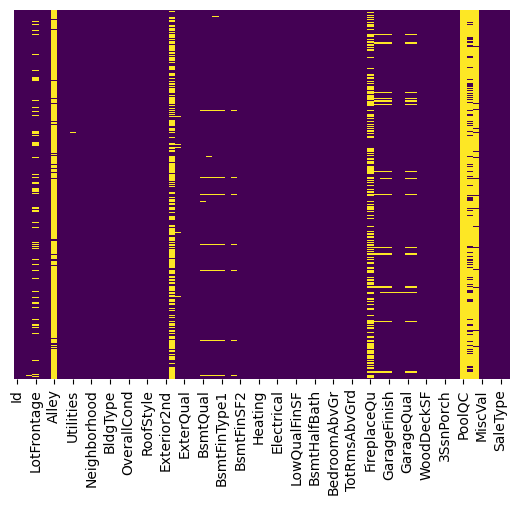

In [57]:
sb.heatmap(df.isnull(), yticklabels = False, cbar = False, cmap = 'viridis')

In [58]:
pd.set_option('display.max_rows', None)
df.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,4
LotFrontage,227
LotArea,0
Street,0
Alley,1352
LotShape,0
LandContour,0
Utilities,2


In [59]:
df['MSZoning'] = df['MSZoning'].fillna(df['MSZoning'].mode()[0])

In [60]:
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].mean())

In [61]:
df.drop(columns=['Alley'], axis = 1, inplace=True)

In [62]:
df.drop(columns=['MasVnrType'], axis = 1, inplace=True)

In [63]:
df.drop(columns=['FireplaceQu'], axis = 1, inplace=True)

In [64]:
df.drop(columns=['PoolQC'], axis = 1, inplace=True)

In [65]:
df.drop(columns=['Fence'], axis = 1, inplace=True)

In [66]:
df.drop(columns=['MiscFeature'], axis = 1, inplace=True)

In [67]:
df['BsmtQual'].value_counts()

,count
BsmtQual,
TA,634
Gd,591
Ex,137
Fa,53


In [68]:
df['BsmtCond'].value_counts()

,count
BsmtCond,
TA,1295
Fa,59
Gd,57
Po,3


In [69]:
df['BsmtQual'] = df['BsmtQual'].fillna(df['BsmtQual'].mode()[0])
df['BsmtCond'] = df['BsmtCond'].fillna(df['BsmtCond'].mode()[0])

In [70]:
df['BsmtExposure'] = df['BsmtExposure'].fillna(df['BsmtExposure'].mode()[0])
df['BsmtFinType1'] = df['BsmtFinType1'].fillna(df['BsmtFinType1'].mode()[0])
df['BsmtFinType2'] = df['BsmtFinType2'].fillna(df['BsmtFinType2'].mode()[0])

In [71]:
df['GarageType'] = df['GarageType'].fillna(df['GarageType'].mode()[0])
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['GarageYrBlt'].mode()[0])
df['GarageFinish'] = df['GarageFinish'].fillna(df['GarageFinish'].mode()[0])
df['GarageQual'] = df['GarageQual'].fillna(df['GarageQual'].mode()[0])
df['GarageCond'] = df['GarageCond'].fillna(df['GarageCond'].mode()[0])


In [72]:
df['MasVnrArea'] = df['MasVnrArea'].fillna(df['MasVnrArea'].mean())

In [73]:
df.dropna(inplace=True)

In [74]:
df.shape

(1449, 74)

In [79]:
df.dropna(inplace=True)

In [80]:
df.to_csv('formulatedTest.csv', index = False)